In [1]:
import torch
import torch.nn as nn
import torchaudio.transforms as T
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader, Dataset
from torchvision.models import convnext_tiny
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, roc_auc_score

# OPTIMISATION RTX 4070 Super : Active les cœurs Tensor (TF32)
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Exécution sur : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

Exécution sur : NVIDIA GeForce RTX 4070 SUPER


In [2]:
class GPUAugmenter(nn.Module):
    def __init__(self, sr=22050):
        super().__init__()
        self.sr = sr
        self.mel_spec = T.MelSpectrogram(
            sample_rate=sr, n_fft=1024, hop_length=512, n_mels=128, 
            center=True, pad_mode="reflect", power=2.0
        )
        # On utilise AmplitudeToDB avec une valeur de référence pour plus de stabilité
        self.amplitude_to_db = T.AmplitudeToDB(stype='power', top_db=80.0)
        
        self.freq_mask = T.FrequencyMasking(freq_mask_param=15)
        self.time_mask = T.TimeMasking(time_mask_param=35)
        self.pitch_shift = T.PitchShift(sample_rate=sr, n_steps=2)

    def forward(self, x, augment=True):
        # Sécurité : On s'assure que l'entrée n'a pas de NaNs
        x = torch.nan_to_num(x)

        if augment:
            if torch.rand(1) < 0.3:
                x = x + 0.001 * torch.randn_like(x)
            if torch.rand(1) < 0.2:
                x = self.pitch_shift(x)

        # 1. Calcul du spectrogramme
        spec = self.mel_spec(x)
        
        # 2. Sécurité CRITIQUE : ajouter un epsilon avant le log (dB)
        # Cela empêche log(0) qui donne -inf
        spec = self.amplitude_to_db(spec + 1e-10)

        if augment:
            if torch.rand(1) < 0.4: spec = self.freq_mask(spec)
            if torch.rand(1) < 0.4: spec = self.time_mask(spec)

        # 3. Normalisation Robuste (Standardisation)
        # Au lieu du Min-Max qui est sensible aux valeurs extrêmes
        mean = spec.mean()
        std = spec.std() + 1e-8
        spec = (spec - mean) / std
        
        return spec

class FastAudioDataset(Dataset):
    def __init__(self, x_audio, y_labels):
        self.x = x_audio
        self.y = y_labels
    def __len__(self): return len(self.y)
    def __getitem__(self, idx):
        # On charge le signal brut (beaucoup plus léger pour le transfert CPU -> GPU)
        audio = torch.tensor(self.x[idx], dtype=torch.float32).unsqueeze(0)
        label = torch.tensor(self.y[idx], dtype=torch.long)
        return audio, label

In [3]:
directory = "C:/Users/lrozier/Documents/UQAC/respiratory-disease-detection/data/processed/"

# ATTENTION : Pour l'augmenter GPU, on charge les signaux BRUTS (X_raw ou équivalent)
# Si tes signaux bruts s'appellent X_raw.npy :
try:
    X = np.load(directory + "X.npy") # <--- Vérifie le nom de ton fichier de signaux bruts
    y = np.load(directory + "y.npy")
    print(f"Données chargées : X={X.shape}, y={y.shape}")
except:
    print("Erreur : Fichier X.npy non trouvé. Vérifie le nom de tes signaux bruts.")

# Encodage des labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split en train, validation et test
split1 = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, temp_idx = next(split1.split(X, y_encoded))

X_train, X_temp = X[train_idx], X[temp_idx]
y_train, y_temp = y_encoded[train_idx], y_encoded[temp_idx]

split2 = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_idx, test_idx = next(split2.split(X_temp, y_temp))

X_val, X_test = X_temp[val_idx], X_temp[test_idx]
y_val, y_test = y_temp[val_idx], y_temp[test_idx]
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Données chargées : X=(1201, 132300), y=(1201,)
Train: (840, 132300), Val: (180, 132300), Test: (181, 132300)


In [20]:
# --- INITIALISATION DATA ---
# Remarque : Utilisez vos variables X_train, y_train, X_val, y_val issues du signal brut
augmenter = GPUAugmenter(sr=22050).to(device)

train_loader = DataLoader(FastAudioDataset(X_train, y_train), batch_size=64, shuffle=True, pin_memory=True)
val_loader = DataLoader(FastAudioDataset(X_val, y_val), batch_size=64, pin_memory=True)

# --- MODÈLE CONVNEXT TINY ---
model = convnext_tiny(weights="DEFAULT")

# Adaptation 1 canal (Niveaux de gris / Spectrogramme)
old_conv = model.features[0][0]
model.features[0][0] = nn.Conv2d(1, old_conv.out_channels, kernel_size=4, stride=4)
with torch.no_grad():
    model.features[0][0].weight.data = old_conv.weight.data.mean(dim=1, keepdim=True)

# Classifieur robuste
model.classifier = nn.Sequential(
    nn.LayerNorm((768, 1, 1), eps=1e-6),
    nn.Flatten(1),
    nn.Linear(768, 256), nn.ReLU(), nn.Dropout(0.3),
    nn.Linear(256, 5) # 5 classes médicales
)
model.to(device)

criterion = nn.CrossEntropyLoss()
scaler = torch.amp.GradScaler('cuda')

In [12]:
best_acc = 0.0
history = {"train_loss": [], "val_acc": []}

phases = [
    {"name": "Warmup (Freeze)", "epochs": 10, "lr": 1e-3, "freeze": True},
    {"name": "Fine-Tuning (Unfreeze)", "epochs": 100, "lr": 5e-5, "freeze": False}
]

for p_info in phases:
    print(f"\n>>> DÉBUT PHASE : {p_info['name']}")
    
    # Gestion du Freeze/Unfreeze
    for param in model.features.parameters():
        param.requires_grad = not p_info['freeze']
    
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), 
                                  lr=p_info['lr'], weight_decay=1e-4)

    for epoch in range(p_info['epochs']):
        model.train()
        total_loss = 0
        for audios, labels in train_loader:
            audios, labels = audios.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast('cuda'):
                # Augmentation GPU !
                specs = augmenter(audios, augment=(not p_info['freeze']))
                outputs = model(specs)
                loss = criterion(outputs, labels)
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            total_loss += loss.item()

        # Validation
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for audios, labels in val_loader:
                audios, labels = audios.to(device), labels.to(device)
                with torch.amp.autocast('cuda'):
                    specs = augmenter(audios, augment=False)
                    outputs = model(specs)
                correct += (outputs.argmax(1) == labels).sum().item()
                total += labels.size(0)
        
        acc = correct / total
        history["train_loss"].append(total_loss/len(train_loader))
        history["val_acc"].append(acc)
        
        print(f"Epoch {epoch+1}/{p_info['epochs']} | Loss: {total_loss/len(train_loader):.4f} | Val Acc: {acc:.2%}")
        
        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), "best_model_respiratory.pth")


>>> DÉBUT PHASE : Warmup (Freeze)
Epoch 1/10 | Loss: 0.0008 | Val Acc: 92.78%
Epoch 2/10 | Loss: 0.0011 | Val Acc: 92.22%
Epoch 3/10 | Loss: 0.0007 | Val Acc: 91.67%
Epoch 4/10 | Loss: 0.0035 | Val Acc: 92.22%
Epoch 5/10 | Loss: 0.0005 | Val Acc: 93.33%
Epoch 6/10 | Loss: 0.0655 | Val Acc: 92.22%
Epoch 7/10 | Loss: 0.0019 | Val Acc: 91.67%
Epoch 8/10 | Loss: 0.0032 | Val Acc: 92.78%
Epoch 9/10 | Loss: 0.0015 | Val Acc: 93.33%
Epoch 10/10 | Loss: 0.0009 | Val Acc: 92.78%

>>> DÉBUT PHASE : Fine-Tuning (Unfreeze)
Epoch 1/100 | Loss: 0.1017 | Val Acc: 90.00%
Epoch 2/100 | Loss: 0.0721 | Val Acc: 86.11%
Epoch 3/100 | Loss: 0.0328 | Val Acc: 92.22%
Epoch 4/100 | Loss: 0.0060 | Val Acc: 93.33%
Epoch 5/100 | Loss: 0.0919 | Val Acc: 92.78%
Epoch 6/100 | Loss: 0.0833 | Val Acc: 90.00%
Epoch 7/100 | Loss: 0.0553 | Val Acc: 91.11%
Epoch 8/100 | Loss: 0.0403 | Val Acc: 91.67%
Epoch 9/100 | Loss: 0.0404 | Val Acc: 92.78%
Epoch 10/100 | Loss: 0.0224 | Val Acc: 91.11%
Epoch 11/100 | Loss: 0.0236 | V

ÉVALUATION DU MODÈLE SUR LE JEU DE TEST

Accuracy globale:        0.9392
Macro F1-score:          0.9317  <- Métrique clé
Weighted F1-score:       0.9403

RAPPORT DE CLASSIFICATION PAR CLASSE

(Sensibilité = Recall = % de vrais positifs détectés par classe)
              precision    recall  f1-score   support

      asthma     0.9750    0.9070    0.9398        43
   bronchial     1.0000    0.9333    0.9655        15
        copd     1.0000    0.9508    0.9748        61
     healthy     0.8182    0.9000    0.8571        20
   pneumonia     0.8723    0.9762    0.9213        42

    accuracy                         0.9392       181
   macro avg     0.9331    0.9335    0.9317       181
weighted avg     0.9443    0.9392    0.9403       181



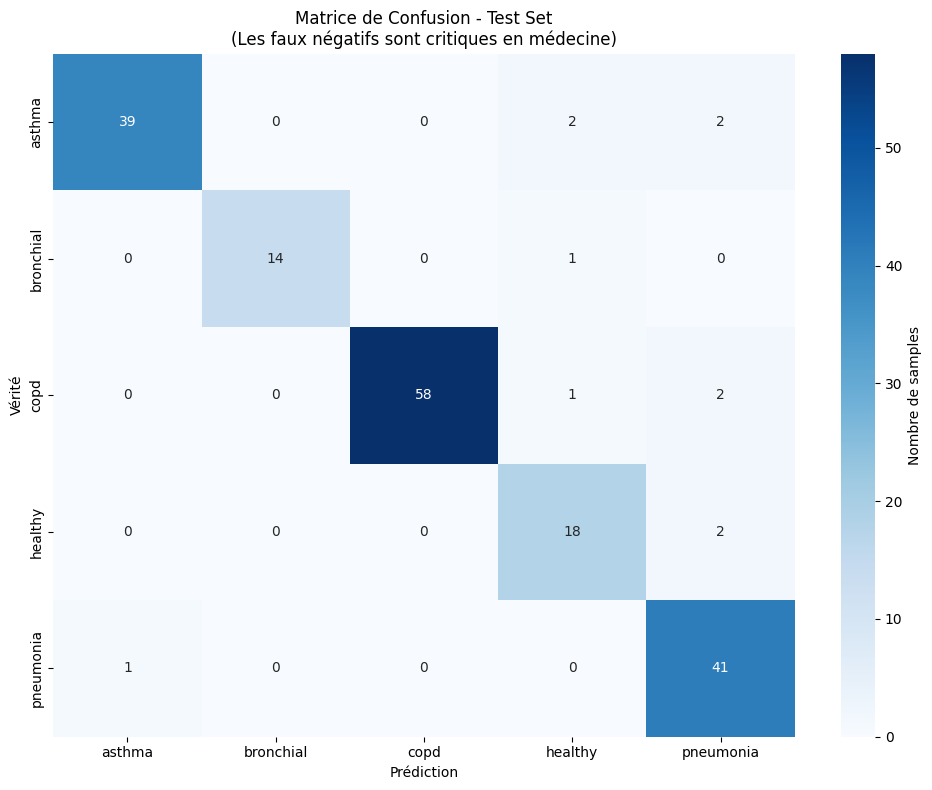


ANALYSE DES ERREURS - FAUX NÉGATIFS PAR CLASSE
asthma         : FN=  4, TP= 39, Sensibilité=0.9070
bronchial      : FN=  1, TP= 14, Sensibilité=0.9333
copd           : FN=  3, TP= 58, Sensibilité=0.9508
healthy        : FN=  2, TP= 18, Sensibilité=0.9000
pneumonia      : FN=  1, TP= 41, Sensibilité=0.9762

AUC-ROC PAR CLASSE
asthma         : AUC-ROC = 0.9920
bronchial      : AUC-ROC = 1.0000
copd           : AUC-ROC = 0.9974
healthy        : AUC-ROC = 0.9885
pneumonia      : AUC-ROC = 0.9932

Moyenne AUC-ROC: 0.9942


In [22]:
# 1. Utilisation du FastAudioDataset pour le test (Charge l'audio brut)
test_loader = DataLoader(FastAudioDataset(X_test, y_test), batch_size=64, shuffle=False, pin_memory=True)


model.load_state_dict(torch.load("../models/best_model_respiratory.pth"))

# 2. Faire les prédictions sur le test set
model.eval()
y_test_pred = []
y_test_proba = []

with torch.no_grad():
    for audios, labels in test_loader:
        # On envoie l'audio brut sur la 4070
        audios = audios.to(device, non_blocking=True)
        
        with torch.amp.autocast('cuda'):
            # Transformation en Spectrogramme sur GPU (sans augmentation)
            specs = augmenter(audios, augment=False)
            
            # Prédiction du modèle
            outputs = model(specs)
            
        proba = torch.nn.functional.softmax(outputs, dim=1)
        y_test_pred.extend(outputs.argmax(dim=1).cpu().numpy())
        y_test_proba.extend(proba.cpu().numpy())

y_test_pred = np.array(y_test_pred)
y_test_proba = np.array(y_test_proba)

print("="*70)
print("ÉVALUATION DU MODÈLE SUR LE JEU DE TEST")
print("="*70)

accuracy = accuracy_score(y_test, y_test_pred)
macro_f1 = f1_score(y_test, y_test_pred, average='macro')
weighted_f1 = f1_score(y_test, y_test_pred, average='weighted')

print(f"\nAccuracy globale:        {accuracy:.4f}")
print(f"Macro F1-score:          {macro_f1:.4f}  <- Métrique clé")
print(f"Weighted F1-score:       {weighted_f1:.4f}")

print("\n" + "="*70)
print("RAPPORT DE CLASSIFICATION PAR CLASSE")
print("="*70)
print("\n(Sensibilité = Recall = % de vrais positifs détectés par classe)")
print(classification_report(y_test, y_test_pred,
                          target_names=le.classes_,
                          digits=4,
                          zero_division=0))

cm = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            cbar_kws={'label': 'Nombre de samples'}, ax=ax)
ax.set_xlabel('Prédiction')
ax.set_ylabel('Vérité')
ax.set_title('Matrice de Confusion - Test Set\n(Les faux négatifs sont critiques en médecine)')
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("ANALYSE DES ERREURS - FAUX NÉGATIFS PAR CLASSE")
print("="*70)
for i, class_name in enumerate(le.classes_):
    fn = cm[i, :].sum() - cm[i, i]
    tp = cm[i, i]
    sensibilite = tp / (tp + fn) if (tp + fn) > 0 else 0
    print(f"{class_name:15s}: FN={fn:3d}, TP={tp:3d}, Sensibilité={sensibilite:.4f}")

print("\n" + "="*70)
print("AUC-ROC PAR CLASSE")
print("="*70)

y_test_onehot = np.eye(len(le.classes_))[y_test]

auc_scores = []
for i, class_name in enumerate(le.classes_):
    try:
        auc_score = roc_auc_score(y_test_onehot[:, i], y_test_proba[:, i])
        auc_scores.append(auc_score)
        print(f"{class_name:15s}: AUC-ROC = {auc_score:.4f}")
    except Exception:
        print(f"{class_name:15s}: AUC-ROC = N/A (classe insuffisante)")

mean_auc = np.mean(auc_scores) if auc_scores else 0
print(f"\nMoyenne AUC-ROC: {mean_auc:.4f}")

Nombre total d'erreurs : 12


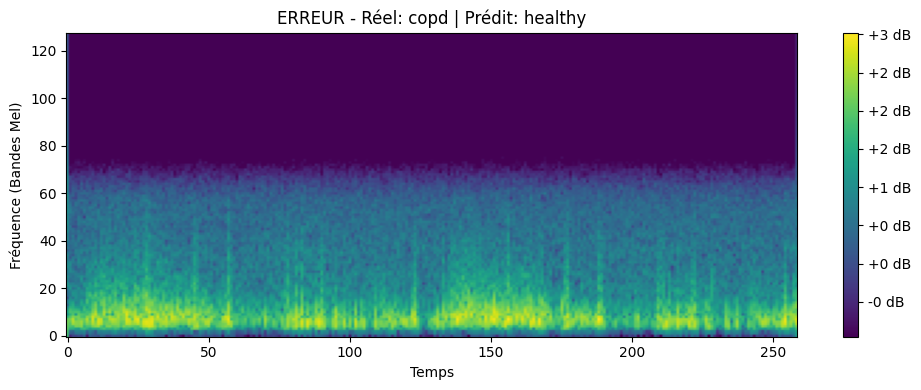

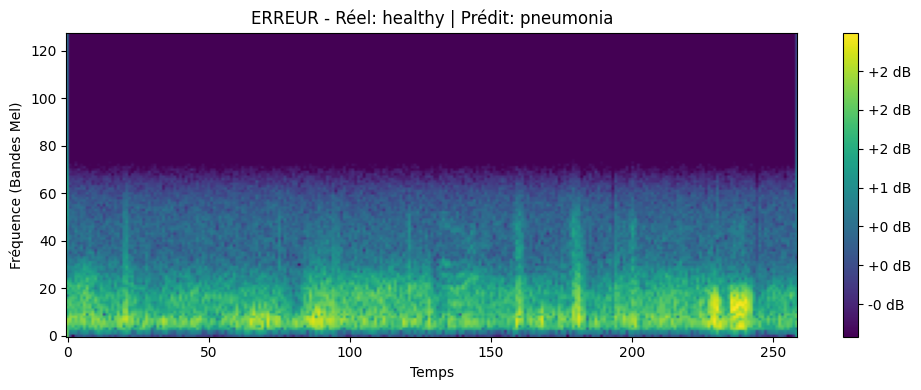

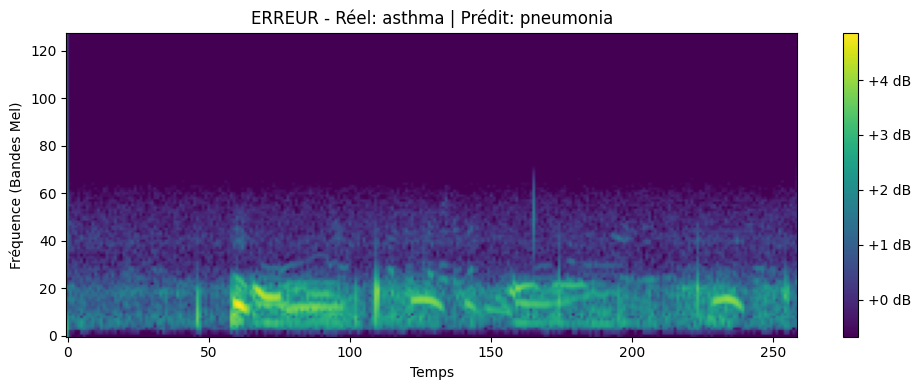

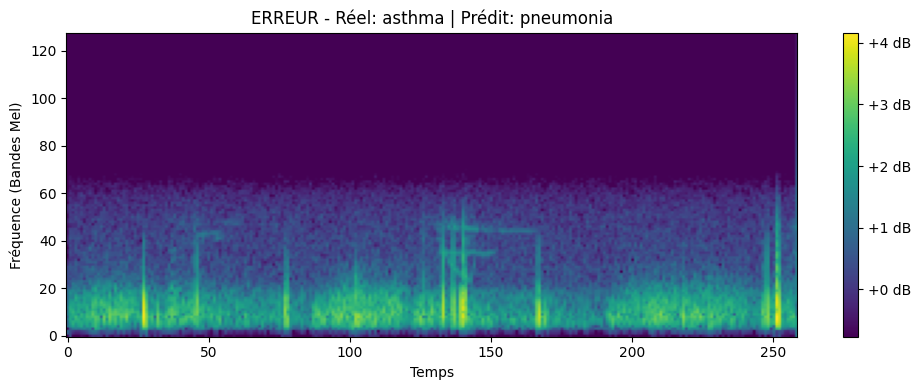

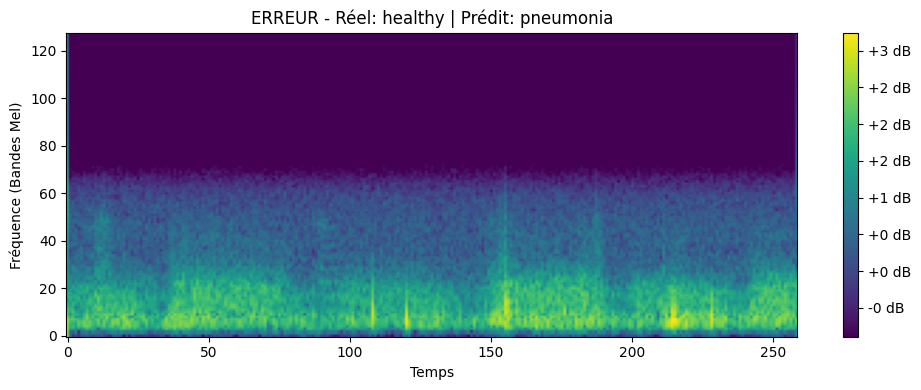

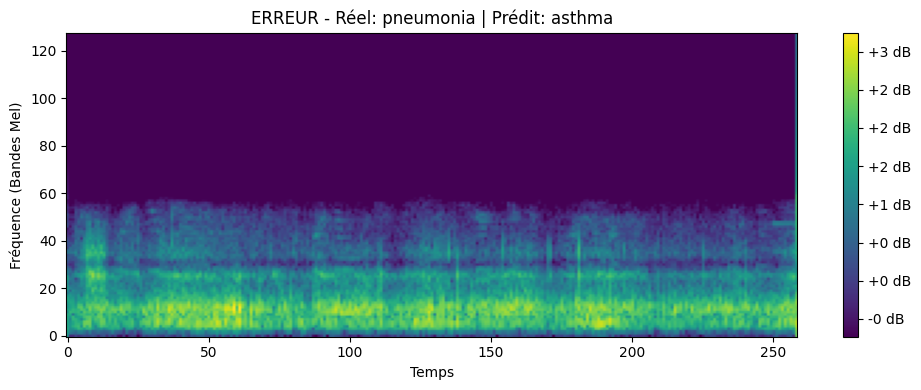

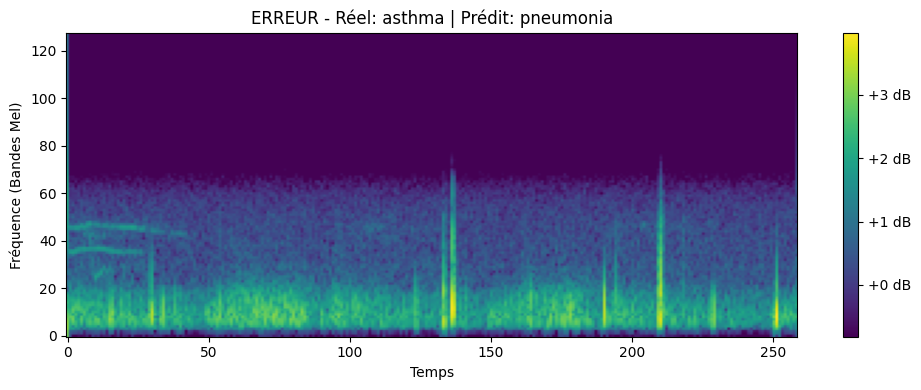

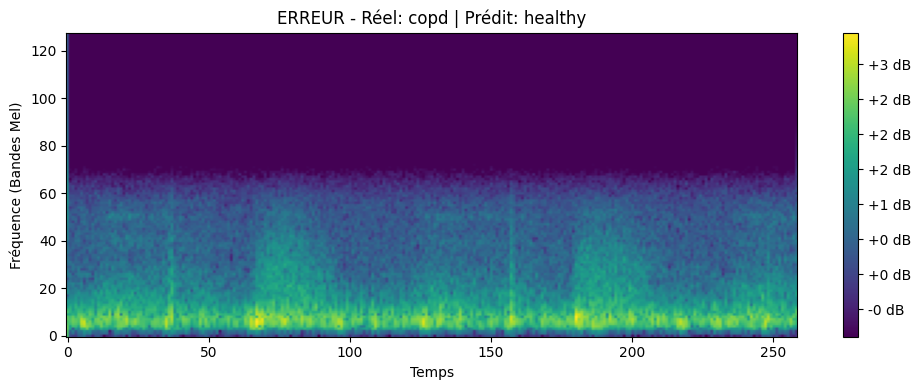

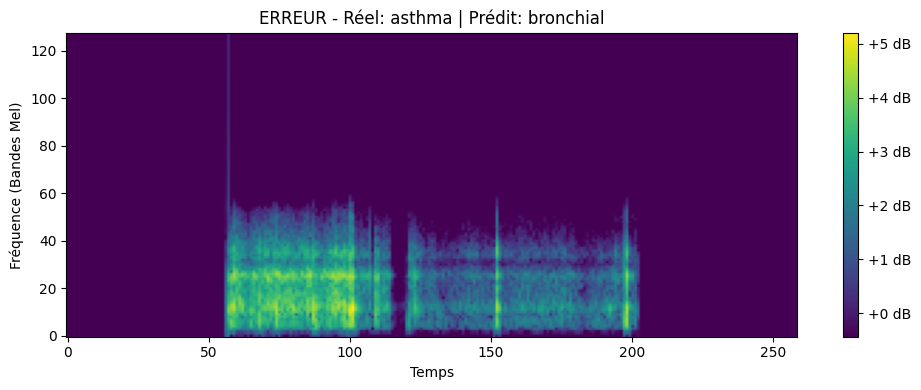

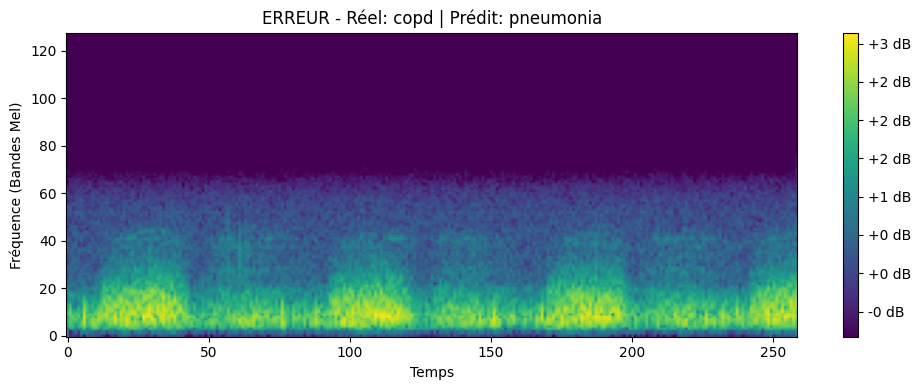

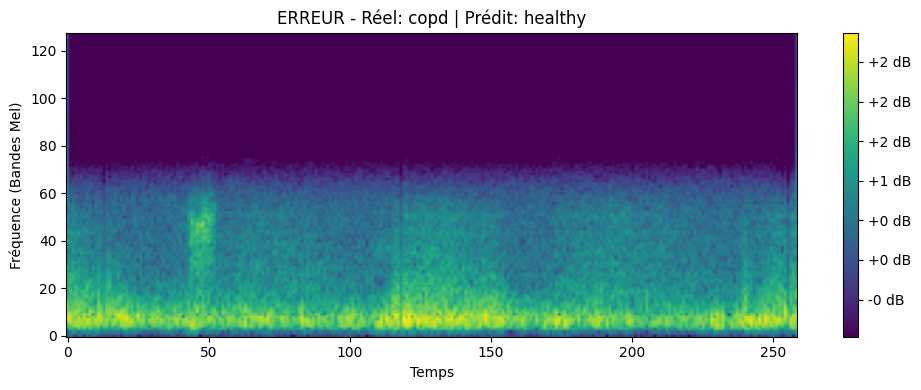

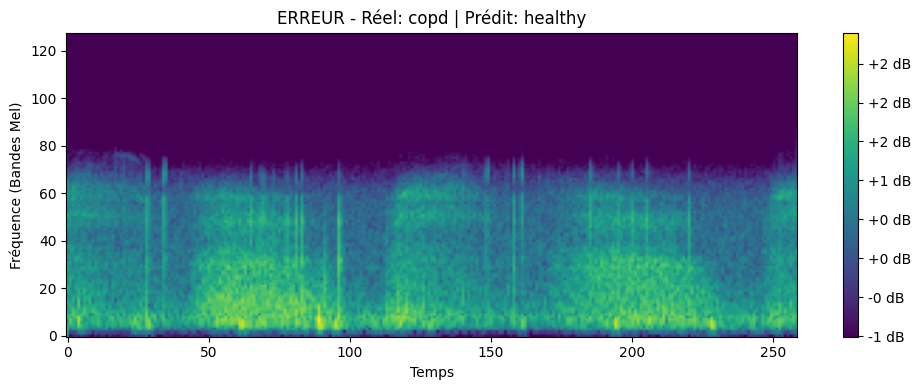

In [14]:
# Masque des erreurs (indices où la prédiction est différente de la réalité)
errors_indices = np.where(y_test != y_test_pred)[0]

print(f"Nombre total d'erreurs : {len(errors_indices)}")

augmenter.eval()

for idx in errors_indices[:]:
    plt.figure(figsize=(10, 4))
    
    raw_audio = torch.tensor(X_test[idx], dtype=torch.float32).unsqueeze(0).to(device)
    with torch.no_grad():
        with torch.amp.autocast('cuda'):
            spec_tensor = augmenter(raw_audio, augment=False)
            
    spec_numpy = spec_tensor.squeeze().cpu().numpy()
    plt.imshow(spec_numpy, aspect='auto', origin='lower', cmap='viridis')
    
    real_class = le.classes_[y_test[idx]]
    pred_class = le.classes_[y_test_pred[idx]]
    
    plt.title(f"ERREUR - Réel: {real_class} | Prédit: {pred_class}")
    plt.colorbar(format='%+2.0f dB')
    plt.xlabel('Temps')
    plt.ylabel('Fréquence (Bandes Mel)')
    plt.tight_layout()
    plt.show()